In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [18]:
df=pd.read_csv('/content/gold_prices.csv')
df

,Price,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN
2,2006-04-07,588.4000244140625,598.2999877929688,585.5,595.5,450
3,2006-04-10,597.5999755859375,599.0,589.0,589.0,316
4,2006-04-11,595.2000122070312,604.0,595.0,602.0,697
...,...,...,...,...,...,...
5026,2026-03-31,4647.60009765625,4684.10009765625,4508.60009765625,4510.0,4264
5027,2026-04-01,4783.2001953125,4789.10009765625,4668.0,4668.39990234375,1637
5028,2026-04-02,4651.5,4784.39990234375,4558.89990234375,4764.89990234375,0
5029,2026-04-06,4656.7998046875,4689.60009765625,4605.0,4656.10009765625,0


In [19]:
data=df

In [20]:
data.shape

(5031, 6)

In [21]:
data.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5031 entries, 0 to 5030
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   5031 non-null   object
 1   Close   5030 non-null   object
 2   High    5030 non-null   object
 3   Low     5030 non-null   object
 4   Open    5030 non-null   object
 5   Volume  5030 non-null   object
dtypes: object(6)
memory usage: 236.0+ KB


In [23]:
data.isnull().sum()

,0
Price,0
Close,1
High,1
Low,1
Open,1
Volume,1


In [24]:
data.dropna(inplace=True)

In [25]:
data = df.copy()
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')
data.dropna(subset=['Close', 'High', 'Low', 'Open', 'Volume'], inplace=True)
Q1=data.quantile(0.25, numeric_only=True)
Q3=data.quantile(0.75, numeric_only=True)
IQR=Q3-Q1
print(IQR)

Close     601.800049
High      604.300049
Low       601.199951
Open      603.299927
Volume    504.000000
dtype: float64


In [26]:
data.index=data.index+1

In [27]:
data

,Price,Close,High,Low,Open,Volume
3,2006-04-07,588.400024,598.299988,585.500000,595.500000,450.0
4,2006-04-10,597.599976,599.000000,589.000000,589.000000,316.0
5,2006-04-11,595.200012,604.000000,595.000000,602.000000,697.0
6,2006-04-12,597.500000,600.000000,597.299988,597.299988,38.0
7,2006-04-13,596.500000,597.500000,592.000000,596.500000,107.0
...,...,...,...,...,...,...
5027,2026-03-31,4647.600098,4684.100098,4508.600098,4510.000000,4264.0
5028,2026-04-01,4783.200195,4789.100098,4668.000000,4668.399902,1637.0
5029,2026-04-02,4651.500000,4784.399902,4558.899902,4764.899902,0.0
5030,2026-04-06,4656.799805,4689.600098,4605.000000,4656.100098,0.0


In [28]:
data.describe()

,Close,High,Low,Open,Volume
count,5029.000000,5029.000000,5029.000000,5029.000000,5029.000000
mean,1544.255020,1552.881786,1535.315510,1544.312329,5024.987075
std,731.645187,737.878963,725.125975,731.839455,26721.053801
min,562.000000,568.799988,555.000000,555.000000,0.000000
25%,1183.500000,1190.000000,1176.500000,1183.400024,42.000000
50%,1332.300049,1339.400024,1325.800049,1332.800049,157.000000
75%,1785.300049,1794.300049,1777.699951,1786.699951,546.000000
max,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000


Confidence Interval

In [29]:
import numpy as np
from scipy import stats
Volume = pd.to_numeric(df['Volume'], errors='coerce')
Volume.dropna(inplace=True)
mean=np.mean(Volume)
sem=stats.sem(Volume)
confidence_interval=stats.t.interval(
    confidence=0.95,
    df=len(Volume)-1,
    loc=mean,
    scale=sem
)
print("Sample mean: ",mean)
print("Confidence interval: ",confidence_interval)

Sample mean:  5024.987074965202
Confidence interval:  (np.float64(4286.29164482488), np.float64(5763.682505105524))


Plotting

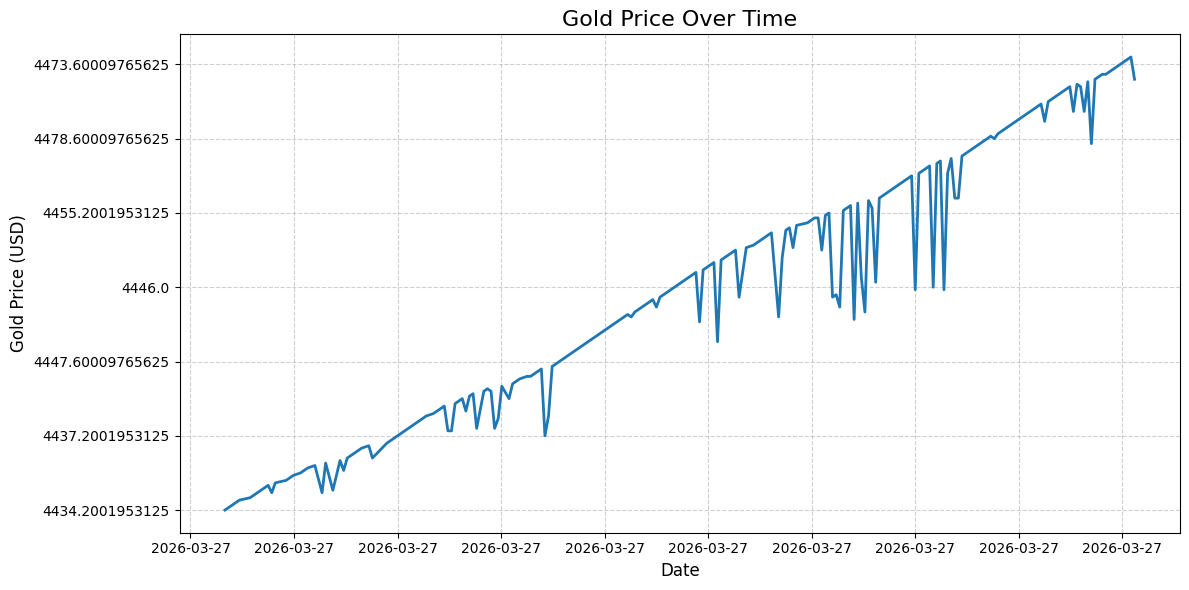

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
df = pd.read_csv("/content/live_gold_dataset.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df.dropna(subset=['Datetime'], inplace=True)
df = df.sort_values('Datetime')
plt.figure(figsize=(12,6))
plt.plot(df['Datetime'], df['Close'], linewidth=2)
plt.title("Gold Price Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (USD)", fontsize=12)
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(8))
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(10))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

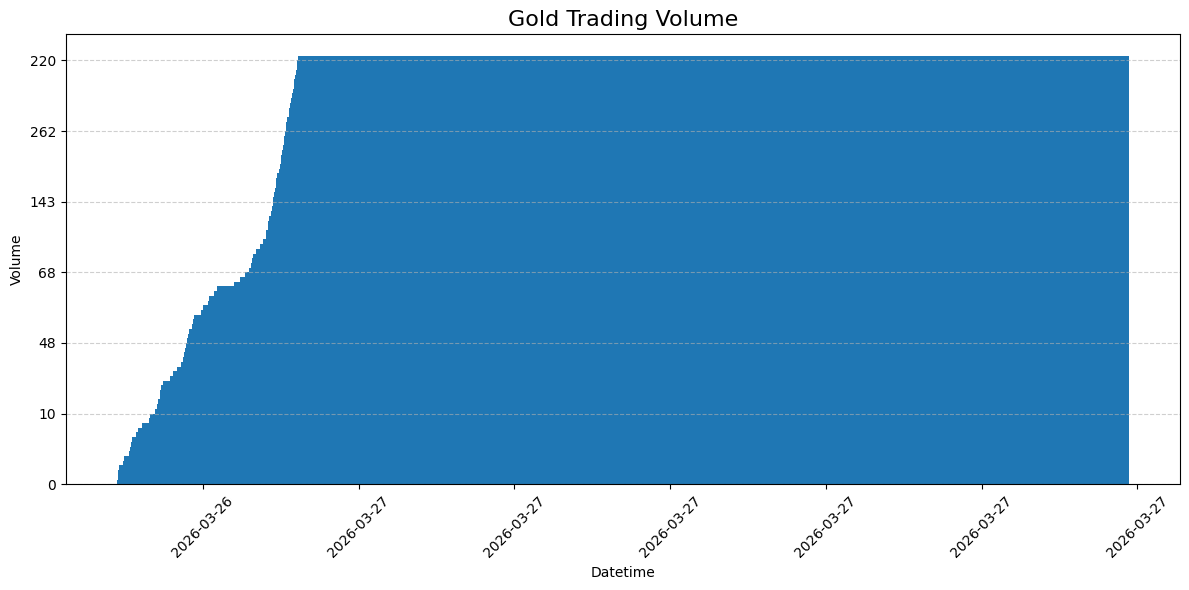

In [31]:
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df.dropna(subset=['Datetime'], inplace=True)
df = df.sort_values('Datetime')
plt.figure(figsize=(12,6))
plt.bar(df['Datetime'], df['Volume'])
plt.title("Gold Trading Volume", fontsize=16)
plt.xlabel("Datetime")
plt.ylabel("Volume")
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(10))
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(8))
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

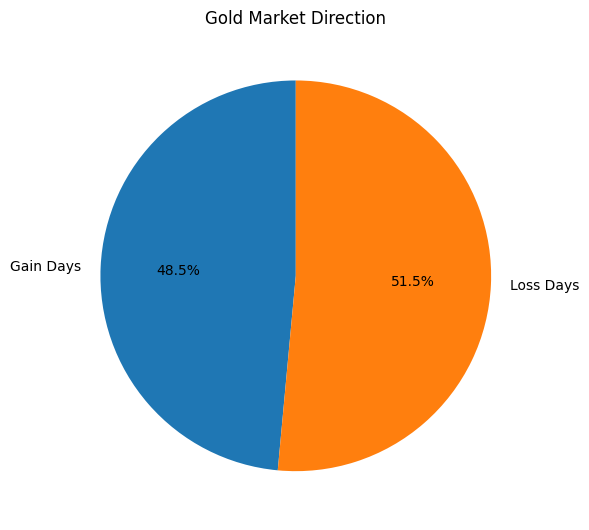

In [32]:
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df.dropna(subset=['Datetime'], inplace=True)
df['Daily Change'] = pd.to_numeric(df['Close'], errors='coerce') - pd.to_numeric(df['Open'], errors='coerce')
df.dropna(subset=['Daily Change'], inplace=True)
gain_days = (df['Daily Change'] > 0).sum()
loss_days = (df['Daily Change'] < 0).sum()
labels = ['Gain Days', 'Loss Days']
sizes = [gain_days, loss_days]
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Gold Market Direction")
plt.tight_layout()
plt.show()

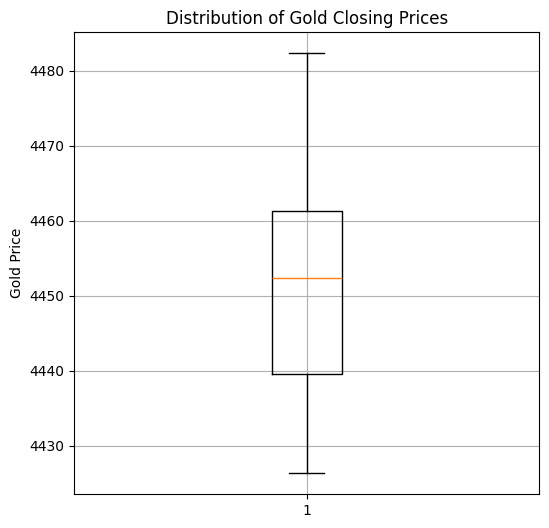

In [33]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df.dropna(subset=['Close'], inplace=True)
plt.figure(figsize=(6,6))
plt.boxplot(df['Close'])
plt.title("Distribution of Gold Closing Prices")
plt.ylabel("Gold Price")
plt.grid(True)
plt.show()

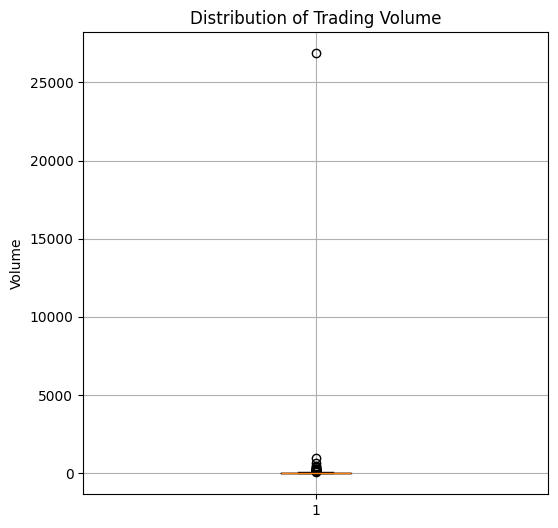

In [34]:
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
df.dropna(subset=['Volume'], inplace=True)
plt.figure(figsize=(6,6))
plt.boxplot(df['Volume'])
plt.title("Distribution of Trading Volume")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

/tmp/ipykernel_514/3847373557.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['Open'], df['High'], df['Low'], df['Close']],


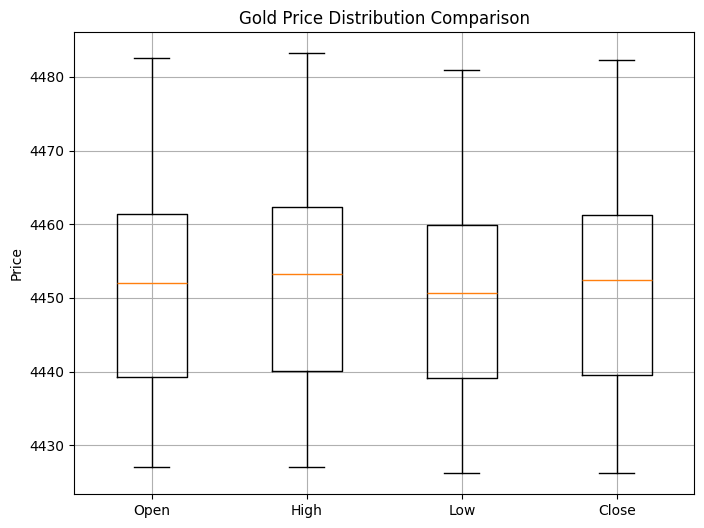

In [35]:
for col in ['Open', 'High', 'Low', 'Close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=['Open', 'High', 'Low', 'Close'], inplace=True)
plt.figure(figsize=(8,6))
plt.boxplot([df['Open'], df['High'], df['Low'], df['Close']],
            labels=['Open','High','Low','Close'])
plt.title("Gold Price Distribution Comparison")
plt.ylabel("Price")
plt.grid(True)
plt.show()

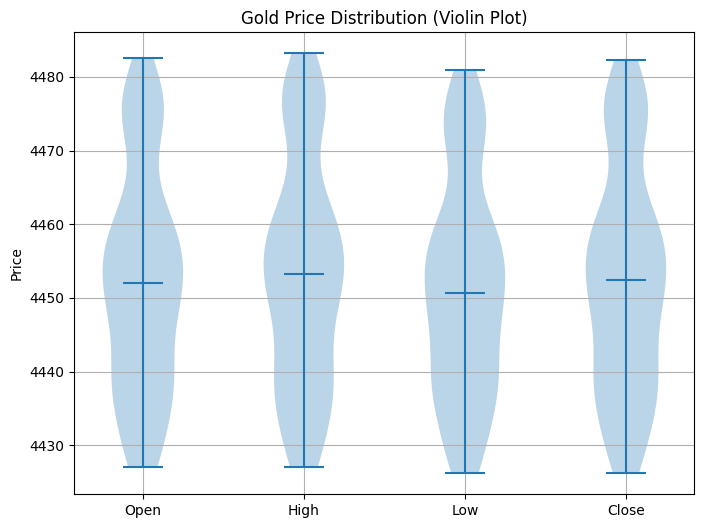

In [36]:
for col in ['Open', 'High', 'Low', 'Close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=['Open', 'High', 'Low', 'Close'], inplace=True)
data = [df['Open'], df['High'], df['Low'], df['Close']]
labels = ['Open','High','Low','Close']
plt.figure(figsize=(8,6))
plt.violinplot(data, showmedians=True)
plt.xticks([1,2,3,4], labels)
plt.title("Gold Price Distribution (Violin Plot)")
plt.ylabel("Price")
plt.grid(True)
plt.show()

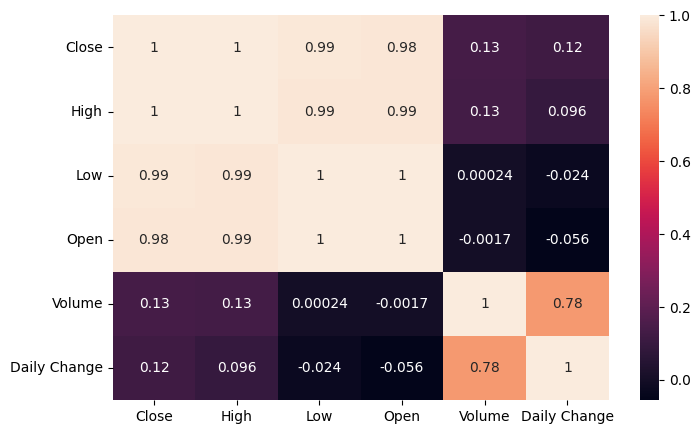

In [37]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

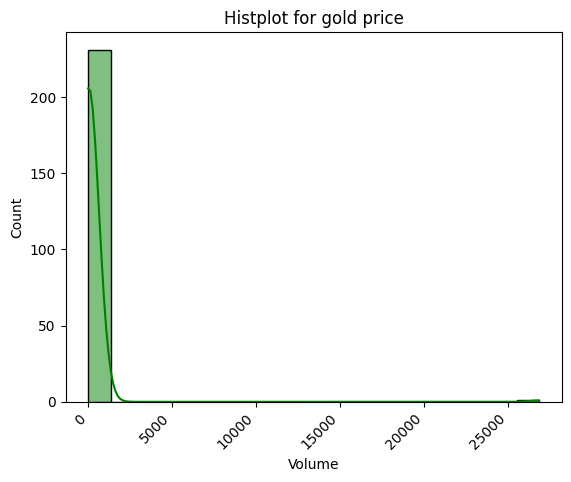

In [38]:
sns.histplot(df['Volume'],bins=20,kde=True,color='green')
plt.title("Histplot for gold price")
plt.xticks(rotation=45,ha='right')
plt.show()

One Sample t-Test

In [39]:
sample = df['Close'].dropna()
t_stat, p_value = stats.ttest_1samp(sample, 4450)
print("Sample mean:", sample.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Sample mean: 4452.506050899111
T-statistic: 2.5410807360323973
P-value: 0.011706718930084094


Two Sample T-test

In [40]:
low_volume = df[df['Volume'] < 50]['Close']
high_volume = df[df['Volume'] >= 50]['Close']
t_stat, p_value = stats.ttest_ind(low_volume, high_volume, equal_var=False)
print("Low volume mean:", low_volume.mean())
print("High volume mean:", high_volume.mean())
print("T statistic:", t_stat)
print("P value:", p_value)

Low volume mean: 4447.9769876887285
High volume mean: 4467.435185185185
T statistic: -9.480117302613378
P value: 8.296936163652419e-15


Paired t-Test

In [41]:
close_prices = df['Close']
open_prices = df['Open']
t_stat, p_value = stats.ttest_rel(close_prices, open_prices)
print("Mean close:", close_prices.mean())
print("Mean open:", open_prices.mean())
print("T statistic:", t_stat)
print("P value:", p_value)


Mean close: 4452.506050899111
Mean open: 4452.294825060614
T statistic: 1.2309012320137898
P value: 0.21961162293495803


One Way Annova

In [42]:
low_volume= df[df['Volume'] < 20]['Close']
medium_volume = df[(df['Volume'] >= 20) & (df['Volume'] < 100)]['Close']
high_volume = df[df['Volume'] >= 100]['Close']
f_stat, p_value = stats.f_oneway(low_volume, medium_volume, high_volume)
print("Low Volume mean:", low_volume.mean())
print("Medium Volume mean:", medium_volume.mean())
print("High Volume mean:", high_volume.mean())
print("F statistic:", f_stat)
print("P value:", p_value)


Low Volume mean: 4446.635475537456
Medium Volume mean: 4456.078361002604
High Volume mean: 4472.293551537298
F statistic: 59.18979324633876
P value: 1.90138945306548e-21


In [43]:
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df.dropna(subset=['Datetime', 'Close'], inplace=True)
sample = df['Close'].dropna()
t_stat, p_value = stats.ttest_1samp(sample, 4450)
print("Sample mean:", sample.mean())
print("T statistic:", t_stat)
print("P value:", p_value)

Sample mean: 4452.506050899111
T statistic: 2.5410807360323973
P value: 0.011706718930084094


Correlation and Covariance

In [44]:
cov_matrix=df[['Volume','Close']].cov()
print('Covariance matrix ',cov_matrix)

Covariance matrix                Volume        Close
Volume  3.109852e+06  3543.478751
Close   3.543479e+03   225.647659


In [45]:
corr_matrix = df[['Volume', 'Close']].corr()
print("Correlation matrix:\n", corr_matrix)

Correlation matrix:
           Volume     Close
Volume  1.000000  0.133766
Close   0.133766  1.000000


Spearman And Pearson's Correlation

In [46]:
pearson_corr, pearson_p = stats.pearsonr(df['Volume'], df['Close'])
print("Pearson correlation:", pearson_corr)
print("P value:", pearson_p)

Pearson correlation: 0.1337656354385701
P value: 0.04178956613666288


In [47]:
spearman_corr, spearman_p = stats.spearmanr(df['Volume'], df['Close'])
print("Spearman correlation:", spearman_corr)
print("P value:", spearman_p)

Spearman correlation: 0.5498089679404405
P value: 9.972389590510752e-20


Model training and testing

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score

In [49]:
X = df[['High','Low','Open','Volume']]
y = df["Close"]#.shift(-1)
#X = X[:-1]
#y = y.dropna()

In [50]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
models={
    "Linear Regression":LinearRegression(),
    "Ridge Regression":Ridge(alpha=1),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest":RandomForestRegressor(n_estimators=100)
}

In [53]:
results=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    mse=mean_squared_error(y_test,y_test)
    r2=r2_score(y_test,y_pred)
    results.append([name,mse,r2])

In [54]:
results_df=pd.DataFrame(results,columns=["Model",'MSE','R2 Score'])
results

[['Linear Regression', 0.0, 0.997283409766729],
 ['Ridge Regression', 0.0, 0.9972813357757652],
 ['Decision Tree', 0.0, 0.9915923040988566],
 ['Random Forest', 0.0, 0.9958006380232542]]

In [55]:
best_model_name = results_df.loc[results_df["R2 Score"].idxmax(), "Model"]
best_model = models[best_model_name]
print(results_df)
print("Best Model:", best_model_name)

               Model  MSE  R2 Score
0  Linear Regression  0.0  0.997283
1   Ridge Regression  0.0  0.997281
2      Decision Tree  0.0  0.991592
3      Random Forest  0.0  0.995801
Best Model: Linear Regression


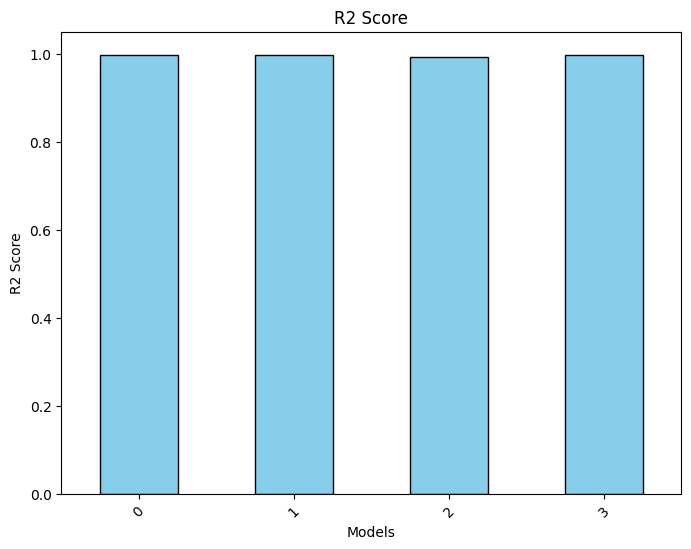

In [56]:
import matplotlib.pyplot as plt
results_df["R2 Score"].plot(kind="bar", figsize=(8,6), color="skyblue", edgecolor="black")
plt.title("R2 Score")
plt.ylabel("R2 Score")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.show()

Pickle File

In [57]:
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("gold_model.pkl", "wb") as f:
    pickle.dump(model, f)
print("Model and scaler saved")

Model and scaler saved
